# Imports


In [3]:
import pandas as pd
import numpy as np
import holidays
import xgboost as xgb
from sklearn.metrics import mean_absolute_error



csv_path= "/Users/nikwe/Downloads/time_series_60min_singleindex_filtered.csv"
weather_data = "/Users/nikwe/Downloads/weather_data_filtered.csv"
df_load =  pd.read_csv(csv_path)
df_weather = pd.read_csv(weather_data)
df_load



,utc_timestamp,cet_cest_timestamp,DE_load_actual_entsoe_transparency,DE_load_forecast_entsoe_transparency,DE_solar_capacity,DE_solar_generation_actual,DE_solar_profile,DE_wind_capacity,DE_wind_generation_actual,DE_wind_profile,...,DE_tennet_load_actual_entsoe_transparency,DE_tennet_load_forecast_entsoe_transparency,DE_tennet_solar_generation_actual,DE_tennet_wind_generation_actual,DE_tennet_wind_offshore_generation_actual,DE_tennet_wind_onshore_generation_actual,DE_transnetbw_load_actual_entsoe_transparency,DE_transnetbw_load_forecast_entsoe_transparency,DE_transnetbw_solar_generation_actual,DE_transnetbw_wind_onshore_generation_actual
0,2014-12-31T23:00:00Z,2015-01-01T00:00:00+0100,NaN,NaN,37248.0,NaN,NaN,27913.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2015-01-01T00:00:00Z,2015-01-01T01:00:00+0100,41151.0,39723.0,37248.0,NaN,NaN,27913.0,8852.0,0.3171,...,13841.0,13362.0,NaN,3866.0,469.0,3398.0,5307.0,4703.0,NaN,5.0
2,2015-01-01T01:00:00Z,2015-01-01T02:00:00+0100,40135.0,38813.0,37248.0,NaN,NaN,27913.0,9054.0,0.3244,...,13267.0,12858.0,NaN,3974.0,466.0,3508.0,5087.0,4562.0,NaN,7.0
3,2015-01-01T02:00:00Z,2015-01-01T03:00:00+0100,39106.0,38490.0,37248.0,NaN,NaN,27913.0,9070.0,0.3249,...,12702.0,12611.0,NaN,4194.0,470.0,3724.0,4906.0,4517.0,NaN,8.0
4,2015-01-01T03:00:00Z,2015-01-01T04:00:00+0100,38765.0,38644.0,37248.0,NaN,NaN,27913.0,9163.0,0.3283,...,12452.0,12490.0,NaN,4446.0,473.0,3973.0,4865.0,4601.0,NaN,11.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
50396,2020-09-30T19:00:00Z,2020-09-30T21:00:00+0200,57559.0,56708.0,NaN,0.0,NaN,NaN,10654.0,NaN,...,17719.0,17190.0,0.0,8186.0,4628.0,3558.0,7657.0,7428.0,NaN,164.0
50397,2020-09-30T20:00:00Z,2020-09-30T22:00:00+0200,54108.0,53270.0,NaN,0.0,NaN,NaN,11836.0,NaN,...,16984.0,16446.0,0.0,8879.0,5056.0,3824.0,7072.0,6870.0,NaN,242.0
50398,2020-09-30T21:00:00Z,2020-09-30T23:00:00+0200,49845.0,49239.0,NaN,0.0,NaN,NaN,12168.0,NaN,...,15549.0,15256.0,0.0,8972.0,5165.0,3807.0,6465.0,6388.0,NaN,257.0
50399,2020-09-30T22:00:00Z,2020-10-01T00:00:00+0200,46886.0,46620.0,NaN,0.0,NaN,NaN,12533.0,NaN,...,14595.0,14586.0,0.0,9049.0,5123.0,3925.0,5963.0,5958.0,NaN,304.0


# Feature Engineering

In [ ]:
#mask = ~df_load['DE_LU_price_day_ahead'].isna()
#df_load = df_load[mask]
#df_load

,utc_timestamp,cet_cest_timestamp,DE_load_actual_entsoe_transparency,DE_load_forecast_entsoe_transparency,DE_solar_capacity,DE_solar_generation_actual,DE_solar_profile,DE_wind_capacity,DE_wind_generation_actual,DE_wind_profile,...,DE_tennet_load_actual_entsoe_transparency,DE_tennet_load_forecast_entsoe_transparency,DE_tennet_solar_generation_actual,DE_tennet_wind_generation_actual,DE_tennet_wind_offshore_generation_actual,DE_tennet_wind_onshore_generation_actual,DE_transnetbw_load_actual_entsoe_transparency,DE_transnetbw_load_forecast_entsoe_transparency,DE_transnetbw_solar_generation_actual,DE_transnetbw_wind_onshore_generation_actual
32856,2018-09-30 23:00:00+00:00,2018-10-01T01:00:00+0200,42126.0,42760.0,46099.0,0.0,0.0,47730.0,6042.0,0.1266,...,12524.0,15069.0,0.0,3461.0,1984.0,1477.0,4893.0,4862.0,0.0,129.0
32857,2018-10-01 00:00:00+00:00,2018-10-01T02:00:00+0200,41500.0,42240.0,46099.0,0.0,0.0,47730.0,6021.0,0.1261,...,12297.0,14855.0,0.0,3629.0,2069.0,1559.0,4849.0,4823.0,0.0,128.0
32858,2018-10-01 01:00:00+00:00,2018-10-01T03:00:00+0200,42353.0,42609.0,46099.0,0.0,0.0,47730.0,6342.0,0.1329,...,12527.0,14946.0,0.0,3846.0,2160.0,1686.0,4985.0,4855.0,0.0,132.0
32859,2018-10-01 02:00:00+00:00,2018-10-01T04:00:00+0200,43802.0,44296.0,46099.0,0.0,0.0,47730.0,7144.0,0.1496,...,13068.0,15343.0,0.0,4235.0,2539.0,1696.0,5198.0,5069.0,0.0,172.0
32860,2018-10-01 03:00:00+00:00,2018-10-01T05:00:00+0200,48065.0,48426.0,46099.0,0.0,0.0,47730.0,7855.0,0.1646,...,14401.0,16599.0,0.0,4593.0,2624.0,1969.0,5800.0,5662.0,0.0,164.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
50395,2020-09-30 18:00:00+00:00,2020-09-30T20:00:00+0200,61177.0,60443.0,NaN,0.0,NaN,NaN,8526.0,NaN,...,18829.0,18155.0,0.0,6745.0,4291.0,2454.0,8200.0,8004.0,NaN,86.0
50396,2020-09-30 19:00:00+00:00,2020-09-30T21:00:00+0200,57559.0,56708.0,NaN,0.0,NaN,NaN,10654.0,NaN,...,17719.0,17190.0,0.0,8186.0,4628.0,3558.0,7657.0,7428.0,NaN,164.0
50397,2020-09-30 20:00:00+00:00,2020-09-30T22:00:00+0200,54108.0,53270.0,NaN,0.0,NaN,NaN,11836.0,NaN,...,16984.0,16446.0,0.0,8879.0,5056.0,3824.0,7072.0,6870.0,NaN,242.0
50398,2020-09-30 21:00:00+00:00,2020-09-30T23:00:00+0200,49845.0,49239.0,NaN,0.0,NaN,NaN,12168.0,NaN,...,15549.0,15256.0,0.0,8972.0,5165.0,3807.0,6465.0,6388.0,NaN,257.0


In [4]:
df_load['utc_timestamp'] = pd.to_datetime(df_load['utc_timestamp'])
df_weather['utc_timestamp'] = pd.to_datetime(df_weather['utc_timestamp'])

# Inner Join auf UTC
df = df_load.merge(df_weather, on='utc_timestamp', how='inner')


In [5]:
df['hour'] = df['utc_timestamp'].dt.hour
df['weekday'] = df['utc_timestamp'].dt.weekday
df['month'] = df['utc_timestamp'].dt.month
# Optional zyklische Features
df['hour_sin'] = np.sin(2 * np.pi * df['hour']/24)
df['hour_cos'] = np.cos(2 * np.pi * df['hour']/24)



df['residual_load'] = df['DE_LU_load_forecast_entsoe_transparency'] - df['DE_LU_wind_generation_actual'] - df['DE_LU_solar_generation_actual']
df['residual_load_lag_24h'] = df['residual_load'].shift(24)

de_holidays = holidays.Germany(years=[2015,2021])  

# Neue Spalte: 1 wenn Feiertag, sonst 0
df['is_holiday'] = df['utc_timestamp'].dt.date.apply(lambda x: 1 if x in de_holidays else 0)
# Setze DatetimeIndex
df = df.set_index('utc_timestamp')
df['is_winter'] = df.index.month.isin([12,1,2]).astype(int)
df['is_summer'] = df.index.month.isin([6,7,8]).astype(int)



# Interpolation durchführen
df['DE_LU_load_forecast_entsoe_transparency'] = df['DE_LU_load_forecast_entsoe_transparency'].interpolate(method='time')

df = df.reset_index()

df['load_lag_1h'] = df['DE_load_actual_entsoe_transparency'].shift(1)
df['load_lag_2h'] = df['DE_load_actual_entsoe_transparency'].shift(2)
df['load_lag_3h'] = df['DE_load_actual_entsoe_transparency'].shift(3)
df['load_lag_24h'] = df['DE_load_actual_entsoe_transparency'].shift(24)
df['load_lag_48h'] = df['DE_load_actual_entsoe_transparency'].shift(48)
df['load_lag_72h'] = df['DE_load_actual_entsoe_transparency'].shift(72)
df['load_lag_168h'] = df['DE_load_actual_entsoe_transparency'].shift(168)
df['load_lag_336h'] = df['DE_load_actual_entsoe_transparency'].shift(336)

# Rolling Statistics
df['load_roll_mean_6h'] = df['DE_load_actual_entsoe_transparency'].rolling(6).mean()
df['load_roll_mean_12h'] = df['DE_load_actual_entsoe_transparency'].rolling(12).mean()
df['load_roll_mean_24h'] = df['DE_load_actual_entsoe_transparency'].rolling(24).mean()
df['load_roll_std_24h']  = df['DE_load_actual_entsoe_transparency'].rolling(24).std()
df['load_roll_std_6h']  = df['DE_load_actual_entsoe_transparency'].rolling(6).std()

# Ramp Feature
df['load_delta_1h'] = df['DE_load_actual_entsoe_transparency'].diff(1)


# Lags
""" df['load_lag_1h'] = df['DE_LU_load_actual_entsoe_transparency'].shift(1)
df['load_lag_2h'] = df['DE_LU_load_actual_entsoe_transparency'].shift(2)
df['load_lag_3h'] = df['DE_LU_load_actual_entsoe_transparency'].shift(3)
df['load_lag_24h'] = df['DE_LU_load_actual_entsoe_transparency'].shift(24)
df['load_lag_48h'] = df['DE_LU_load_actual_entsoe_transparency'].shift(48)
df['load_lag_72h'] = df['DE_LU_load_actual_entsoe_transparency'].shift(72)
df['load_lag_168h'] = df['DE_LU_load_actual_entsoe_transparency'].shift(168)
df['load_lag_336h'] = df['DE_LU_load_actual_entsoe_transparency'].shift(336)

# Rolling Statistics
df['load_roll_mean_6h'] = df['DE_LU_load_actual_entsoe_transparency'].rolling(6).mean()
df['load_roll_mean_12h'] = df['DE_LU_load_actual_entsoe_transparency'].rolling(12).mean()
df['load_roll_mean_24h'] = df['DE_LU_load_actual_entsoe_transparency'].rolling(24).mean()
df['load_roll_std_24h']  = df['DE_LU_load_actual_entsoe_transparency'].rolling(24).std()
df['load_roll_std_6h']  = df['DE_LU_load_actual_entsoe_transparency'].rolling(6).std()

# Ramp Feature
df['load_delta_1h'] = df['DE_LU_load_actual_entsoe_transparency'].diff(1) """

# Lags
df['price_lag_1h'] = df['DE_LU_price_day_ahead'].shift(1)
df['price_lag_2h'] = df['DE_LU_price_day_ahead'].shift(2)
df['price_lag_3h'] = df['DE_LU_price_day_ahead'].shift(3)
df['price_lag_12h'] = df['DE_LU_price_day_ahead'].shift(12)
df['price_lag_24h'] = df['DE_LU_price_day_ahead'].shift(24)
df['price_lag_48h'] = df['DE_LU_price_day_ahead'].shift(48)
df['price_lag_72h'] = df['DE_LU_price_day_ahead'].shift(72)
df['price_lag_168h'] = df['DE_LU_price_day_ahead'].shift(168)
df['price_lag_336h'] = df['DE_LU_price_day_ahead'].shift(336)

# Rolling Volatility
df['price_roll_mean_6h'] = df['DE_LU_price_day_ahead'].rolling(6).mean()
df['price_roll_mean_12h'] = df['DE_LU_price_day_ahead'].rolling(12).mean()
df['price_roll_mean_24h'] = df['DE_LU_price_day_ahead'].rolling(24).mean()
df['price_roll_std_6h']  = df['DE_LU_price_day_ahead'].rolling(6).std()
df['price_roll_std_24h']  = df['DE_LU_price_day_ahead'].rolling(24).std()

# Preis-Rampe
df['price_delta_1h'] = df['DE_LU_price_day_ahead'].diff(1)


df['wind_expected'] = df['DE_wind_profile'] * df['DE_wind_capacity']
df['solar_expected'] = df['DE_solar_profile'] * df['DE_solar_capacity']

df['Is_price_negative'] = (df['DE_LU_price_day_ahead']<0).astype(int)
df['was_negative_1h_ago'] = df['Is_price_negative'].shift(1)





In [6]:
cols_load = [
    'utc_timestamp',
    'DE_temperature',
    'DE_radiation_direct_horizontal',
    'DE_radiation_diffuse_horizontal',
    'DE_load_actual_entsoe_transparency',  # Target
    'hour',
    'weekday',
    'month',
    'hour_sin',
    'hour_cos',
    'is_holiday',
    'is_winter',
    'is_summer',
    'load_delta_1h',
    'load_roll_std_24h',
    'load_roll_std_6h',
    'load_roll_mean_6h',
    'load_roll_mean_12h',
    'load_roll_mean_24h',
    'load_lag_168h',
    'load_lag_24h',
    'load_lag_1h',
    'load_lag_2h',
    'load_lag_3h',
    'load_lag_48h',
    'load_lag_72h',
    'load_lag_336h'
        
]
df_load_model = df[cols_load]

df_load_model = df_load_model.dropna()

df_load_model


,utc_timestamp,DE_temperature,DE_radiation_direct_horizontal,DE_radiation_diffuse_horizontal,DE_load_actual_entsoe_transparency,hour,weekday,month,hour_sin,hour_cos,...,load_roll_mean_12h,load_roll_mean_24h,load_lag_168h,load_lag_24h,load_lag_1h,load_lag_2h,load_lag_3h,load_lag_48h,load_lag_72h,load_lag_336h
337,2015-01-15 00:00:00+00:00,0.794,0.0,0.0,48098.0,0,3,1,0.000000,1.000000,...,61859.333333,61062.208333,48041.0,45320.0,50014.0,53648.0,57358.0,48218.0,44192.0,41151.0
338,2015-01-15 01:00:00+00:00,0.940,0.0,0.0,47108.0,1,3,1,0.258819,0.965926,...,60138.333333,61170.333333,47074.0,44513.0,48098.0,50014.0,53648.0,47184.0,43720.0,40135.0
339,2015-01-15 02:00:00+00:00,1.066,0.0,0.0,47519.0,2,3,1,0.500000,0.866025,...,58502.916667,61274.208333,47228.0,45026.0,47108.0,48098.0,50014.0,47064.0,44011.0,39106.0
340,2015-01-15 03:00:00+00:00,1.328,0.0,0.0,48517.0,3,3,1,0.707107,0.707107,...,56946.166667,61350.125000,48253.0,46695.0,47519.0,47108.0,48098.0,48760.0,45401.0,38765.0
341,2015-01-15 04:00:00+00:00,1.764,0.0,0.0,51717.0,4,3,1,0.866025,0.500000,...,55409.583333,61407.291667,51155.0,50345.0,48517.0,47519.0,47108.0,51849.0,49613.0,38941.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
43820,2019-12-31 19:00:00+00:00,0.767,0.0,0.0,47493.0,19,1,12,-0.965926,0.258819,...,50767.916667,47549.875000,46142.0,53959.0,50151.0,52637.0,53428.0,49806.0,51244.0,64119.0
43821,2019-12-31 20:00:00+00:00,0.656,0.0,0.0,45842.0,20,1,12,-0.866025,0.500000,...,50466.750000,47295.916667,45424.0,51937.0,47493.0,50151.0,52637.0,48362.0,49084.0,59560.0
43822,2019-12-31 21:00:00+00:00,0.476,0.0,0.0,45501.0,21,1,12,-0.707107,0.707107,...,50013.750000,47084.541667,44771.0,50574.0,45842.0,47493.0,50151.0,47950.0,47918.0,56557.0
43823,2019-12-31 22:00:00+00:00,0.226,0.0,0.0,43969.0,22,1,12,-0.500000,0.866025,...,49342.333333,46942.333333,42702.0,47382.0,45501.0,45842.0,47493.0,45146.0,44642.0,52719.0


In [7]:
cols_price = [
    'utc_timestamp',
    'DE_LU_price_day_ahead',              # Target
    #'DE_load_forecast_entsoe_transparency',
    'Is_price_negative',
    'was_negative_1h_ago',
    'wind_expected',
    'solar_expected',
    'DE_temperature',
    'DE_radiation_direct_horizontal',
    'DE_radiation_diffuse_horizontal',
    'hour',
    'weekday',
    'month',
    'hour_sin',
    'hour_cos',
    'residual_load',
    'is_holiday',
    'is_winter',
    'is_summer',
    'price_lag_1h',
    'price_lag_2h',
    'price_lag_3h',
    'price_lag_12h',
    'price_lag_24h',
    'price_lag_48h',
    'price_lag_72h',
    'price_lag_168h',
    'price_lag_336h',
    'price_roll_mean_6h',
    'price_roll_mean_12h',
    'price_roll_mean_24h',
    'price_roll_std_6h',
    'price_roll_std_24h',
    'price_delta_1h',
    'load_lag_24h'
]
df_price_model = df[cols_price]

df_price_model = df_price_model.dropna()

df_price_model


,utc_timestamp,DE_LU_price_day_ahead,Is_price_negative,was_negative_1h_ago,wind_expected,solar_expected,DE_temperature,DE_radiation_direct_horizontal,DE_radiation_diffuse_horizontal,hour,...,price_lag_72h,price_lag_168h,price_lag_336h,price_roll_mean_6h,price_roll_mean_12h,price_roll_mean_24h,price_roll_std_6h,price_roll_std_24h,price_delta_1h,load_lag_24h
33192,2018-10-14 23:00:00+00:00,30.86,0,0.0,14726.3828,0.0,12.841,0.0,0.0,23,...,45.88,50.30,56.10,32.925000,34.935000,29.068750,4.559709,12.454475,-4.07,39536.0
33193,2018-10-15 00:00:00+00:00,29.05,0,0.0,13100.8056,0.0,12.526,0.0,0.0,0,...,45.60,50.16,51.41,31.010000,36.195833,29.408750,2.792089,12.332275,-1.81,38223.0
33194,2018-10-15 01:00:00+00:00,30.06,0,0.0,11725.3172,0.0,12.236,0.0,0.0,1,...,45.64,47.32,47.38,30.536667,37.072500,29.847917,2.644426,12.151155,1.01,38512.0
33195,2018-10-15 02:00:00+00:00,33.00,0,0.0,10720.1526,0.0,11.977,0.0,0.0,2,...,45.80,47.94,47.59,30.816667,38.094167,30.359583,2.826621,12.007781,2.94,38496.0
33196,2018-10-15 03:00:00+00:00,42.00,0,0.0,10272.8784,0.0,11.615,0.0,0.0,3,...,49.64,51.14,51.61,33.316667,38.025833,31.243333,4.752871,12.053278,9.00,38945.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
43795,2019-12-30 18:00:00+00:00,31.58,0,0.0,32359.9128,0.0,0.225,0.0,0.0,18,...,43.99,38.90,48.61,34.901667,32.521667,26.042500,3.290729,11.100556,-7.77,51943.0
43796,2019-12-30 19:00:00+00:00,30.68,0,0.0,32324.5964,0.0,0.025,0.0,0.0,19,...,39.52,35.98,43.50,34.760000,32.408333,25.731667,3.477884,10.848666,-0.90,49806.0
43797,2019-12-30 20:00:00+00:00,29.67,0,0.0,32395.2292,0.0,-0.148,0.0,0.0,20,...,36.67,29.20,40.10,34.103333,32.222500,25.634583,4.061446,10.800451,-1.01,48362.0
43798,2019-12-30 21:00:00+00:00,29.68,0,0.0,31436.6412,0.0,-0.243,0.0,0.0,21,...,35.38,27.26,38.08,33.175000,32.274167,25.616667,4.371658,10.793058,0.01,47950.0


In [120]:


split_date = df_price_model['utc_timestamp'].max() - pd.Timedelta(weeks=4)

train_price_model = df_price_model[df_price_model['utc_timestamp'] < split_date]
test_price_model  = df_price_model[df_price_model['utc_timestamp'] >= split_date]

target = 'DE_LU_price_day_ahead'

df_price_model_Y_train = train_price_model[target]
df_price_model_X_train = train_price_model.drop(columns=['DE_LU_price_day_ahead','utc_timestamp'])

df_price_model_Y_test = test_price_model[target]
df_price_model_X_test = test_price_model.drop(columns=['DE_LU_price_day_ahead','utc_timestamp'])


In [115]:
split_date = df_load_model['utc_timestamp'].max() - pd.Timedelta(weeks=4)

train_load_model = df_load_model[df_load_model['utc_timestamp'] < split_date]
test_load_model  = df_load_model[df_load_model['utc_timestamp'] >= split_date]

target = 'DE_load_actual_entsoe_transparency'

df_load_model_Y_train = train_load_model[target]
df_load_model_X_train = train_load_model.drop(columns=[target, 'utc_timestamp'])

df_load_model_Y_test = test_load_model[target]
df_load_model_X_test = test_load_model.drop(columns=[target, 'utc_timestamp'])

# XGBoost

## XGBoost forecast 1h

In [ ]:
load_model = xgb.XGBRegressor(    n_estimators=10000,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42)

load_model.fit(df_load_model_X_train,df_load_model_Y_train)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [ ]:
y_pred = load_model.predict(df_load_model_X_test)

mae = mean_absolute_error(df_load_model_Y_test,y_pred)
print(mae)

467.68178863298664


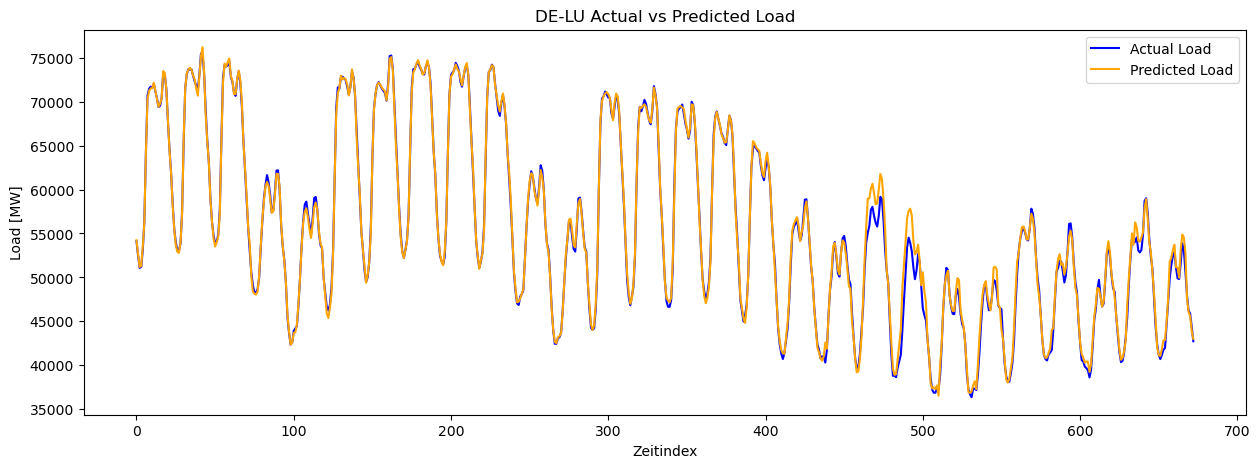

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15,5))

# x-Achse als Index
plt.plot(range(len(df_load_model_Y_test)), df_load_model_Y_test, label='Actual Load', color='blue')
plt.plot(range(len(y_pred)), y_pred, label='Predicted Load', color='orange')

plt.xlabel('Zeitindex')
plt.ylabel('Load [MW]')
plt.title('DE-LU Actual vs Predicted Load')
plt.legend()
plt.show()


In [ ]:
price_model = xgb.XGBRegressor(    n_estimators=10000,
    max_depth=6,
    learning_rate=0.01,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42)

price_model.fit(df_price_model_X_train,df_price_model_Y_train)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [ ]:
y_pred_price = price_model.predict(df_price_model_X_test)

mae = mean_absolute_error(df_price_model_Y_test,y_pred_price)
print(mae)

0.6495920550099187


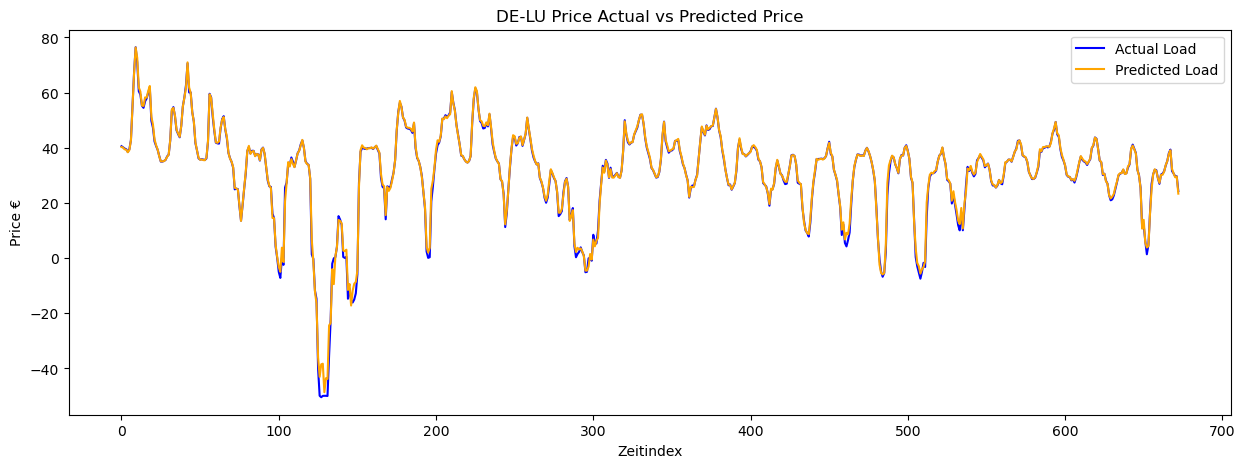

In [118]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15,5))

# x-Achse als Index
plt.plot(range(len(df_price_model_Y_test)), df_price_model_Y_test, label='Actual Load', color='blue')
plt.plot(range(len(y_pred_price)), y_pred_price, label='Predicted Load', color='orange')

plt.xlabel('Zeitindex')
plt.ylabel('Price €')
plt.title('DE-LU Price Actual vs Predicted Price')
plt.legend()
plt.show()

## XGBoost forecast 24h

X_seq shape: (10619, 408)
y_seq shape: (10619, 24)
MAE für 24h Forecast: 1333.57


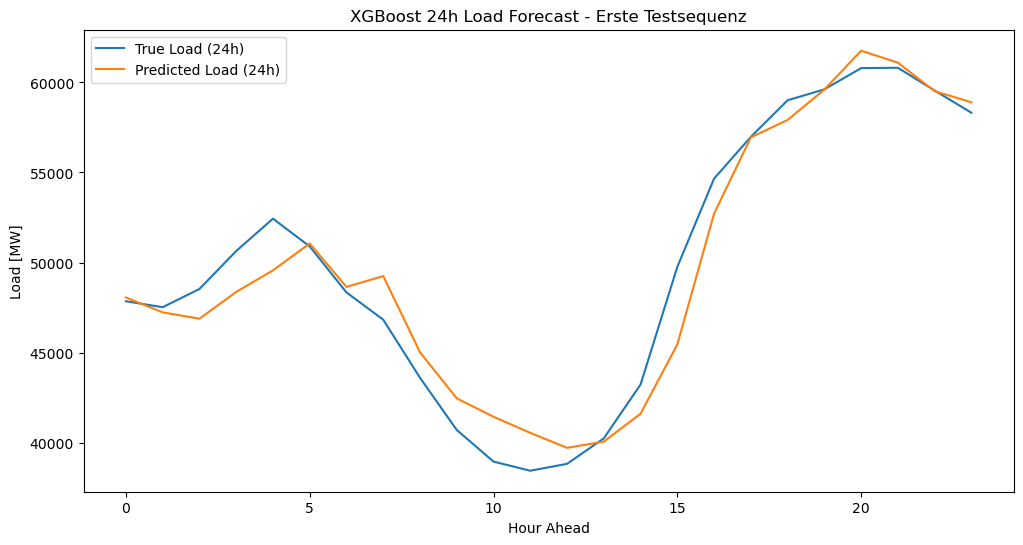

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error
import xgboost as xgb

# =========================
# 1. Daten vorbereiten
# =========================
cols_load = [
    'utc_timestamp',
    'DE_temperature',
    'DE_radiation_direct_horizontal',
    'DE_radiation_diffuse_horizontal',
    'DE_LU_load_actual_entsoe_transparency',  # Target
    'hour',
    'weekday',
    'month',
    'hour_sin',
    'hour_cos',
    'is_holiday',
    'is_winter',
    'is_summer',
    'load_delta_1h',
    'load_roll_std_24h',
    'load_roll_std_6h',
    'load_roll_mean_6h',
    'load_roll_mean_12h',
    'load_roll_mean_24h',
    'load_lag_168h',
    'load_lag_24h',
    'load_lag_1h',
    'load_lag_2h',
    'load_lag_3h',
    'load_lag_48h',
    'load_lag_72h',
    'load_lag_336h'
]

df_load_model = df[cols_load].dropna().reset_index(drop=True)

target_col = 'DE_LU_load_actual_entsoe_transparency'
feature_cols = [c for c in cols_load if c not in ['utc_timestamp', target_col]]

# =========================
# 2. Features & Target
# =========================
X_all = df_load_model[feature_cols].values
y_all = df_load_model[target_col].values

# =========================
# 3. Sequenzen erstellen (24h Input, 24h Forecast)
# =========================
SEQ_LEN = 24  # 24h History
HORIZON = 24  # Forecast 24h

def create_dataset_multi(X, y, seq_len, horizon):
    X_out, y_out = [], []
    for i in range(len(X) - seq_len - horizon + 1):
        X_window = X[i:i+seq_len].flatten()       # flatten 24h history
        y_window = y[i+seq_len:i+seq_len+horizon] # next 24h
        X_out.append(X_window)
        y_out.append(y_window)
    return np.array(X_out), np.array(y_out)

X_seq, y_seq = create_dataset_multi(X_all, y_all, SEQ_LEN, HORIZON)
print("X_seq shape:", X_seq.shape)
print("y_seq shape:", y_seq.shape)

# =========================
# 4. Train/Test Split (80/20)
# =========================
split_idx = int(len(X_seq) * 0.8)
X_train, X_test = X_seq[:split_idx], X_seq[split_idx:]
y_train, y_test = y_seq[:split_idx], y_seq[split_idx:]

# =========================
# 5. XGBoost Multi-Output Modell
# =========================
# Wir trainieren HORIZON einzelne Modelle (1 für jede Stunde)
models = []
for h in range(HORIZON):
    load_model = xgb.XGBRegressor(
        n_estimators=50,
        max_depth=8,
        learning_rate=0.1,
        subsample=0.9,
        colsample_bytree=0.9,
        gamma=0.1,
        objective='reg:squarederror',
        n_jobs=-1,
        random_state=42
    )
    load_model.fit(X_train, y_train[:, h])
    models.append(load_model)

# =========================
# 6. Vorhersage
# =========================
y_pred = np.zeros_like(y_test)
for h in range(HORIZON):
    y_pred[:, h] = models[h].predict(X_test)

# =========================
# 7. MAE berechnen
# =========================
mae = mean_absolute_error(y_test.flatten(), y_pred.flatten())
print(f"MAE für 24h Forecast: {mae:.2f}")

# =========================
# 8. Plot für die erste Testsequenz
# =========================
plt.figure(figsize=(12,6))
plt.plot(range(HORIZON), y_test[0], label='True Load (24h)')
plt.plot(range(HORIZON), y_pred[0], label='Predicted Load (24h)')
plt.xlabel('Hour Ahead')
plt.ylabel('Load [MW]')
plt.title('XGBoost 24h Load Forecast - Erste Testsequenz')
plt.legend()
plt.show()


# LSTM

X shape: (43441, 24, 25)
y shape: (43441, 24)


/Users/nikwe/opt/anaconda3/envs/ds_env/lib/python3.10/site-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_13"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_19 (LSTM)                  │ (None, 64)             │        23,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_26 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_27 (Dense)                │ (None, 24)             │           792 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 25,912 (101.22 KB)

 Trainable params: 25,912 (101.22 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
1990/1990 - 15s - 7ms/step - loss: 0.0800 - val_loss: 0.0442
Epoch 2/50
1990/1990 - 13s - 7ms/step - loss: 0.0449 - val_loss: 0.0379
Epoch 3/50
1990/1990 - 15s - 8ms/step - loss: 0.0406 - val_loss: 0.0366
Epoch 4/50
1990/1990 - 13s - 6ms/step - loss: 0.0386 - val_loss: 0.0341
Epoch 5/50
1990/1990 - 13s - 7ms/step - loss: 0.0374 - val_loss: 0.0351
Epoch 6/50
1990/1990 - 12s - 6ms/step - loss: 0.0358 - val_loss: 0.0326
Epoch 7/50
1990/1990 - 12s - 6ms/step - loss: 0.0354 - val_loss: 0.0314
Epoch 8/50
1990/1990 - 13s - 6ms/step - loss: 0.0340 - val_loss: 0.0317
Epoch 9/50
1990/1990 - 13s - 7ms/step - loss: 0.0337 - val_loss: 0.0305
Epoch 10/50
1990/1990 - 15s - 7ms/step - loss: 0.0331 - val_loss: 0.0336
Epoch 11/50
1990/1990 - 15s - 8ms/step - loss: 0.0330 - val_loss: 0.0296
Epoch 12/50
1990/1990 - 13s - 7ms/step - loss: 0.0320 - val_loss: 0.0311
Epoch 13/50
1990/1990 - 13s - 7ms/step - loss: 0.0316 - val_loss: 0.0313
Epoch 14/50
1990/1990 - 13s - 7ms/step - loss: 0.0313 - val_

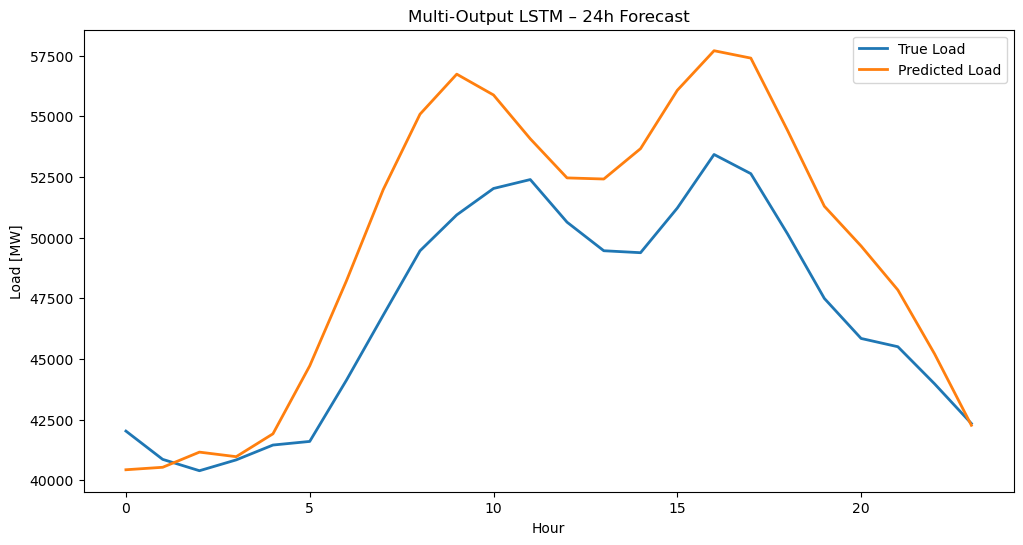


ECHTE MODEL PERFORMANCE:
MAE: 1271.0561143885213
MAPE: 2.3908714138732976 %


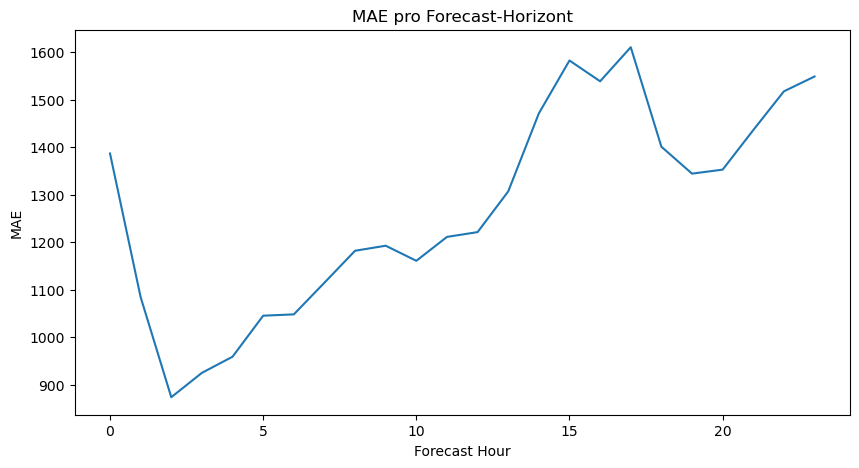

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error
from keras.models import Sequential
from keras.layers import LSTM, Dense, Dropout

# =========================
# SETTINGS
# =========================
SEQ_LEN = 24     # Input: letzte 24h
FORECAST_HORIZON = 24   # Output: nächste 24h

# =========================
# 1. Daten vorbereiten
# =========================
df = df_load_model.copy()
df = df.dropna().reset_index(drop=True)

features = [
    'DE_temperature',
    'DE_radiation_direct_horizontal',
    'DE_radiation_diffuse_horizontal',
    'hour', 'weekday', 'month',
    'hour_sin', 'hour_cos',
    'is_holiday', 'is_winter', 'is_summer',
     'load_delta_1h',
    'load_roll_std_24h',
    'load_roll_std_6h',
    'load_roll_mean_6h',
    'load_roll_mean_12h',
    'load_roll_mean_24h',
    'load_lag_168h',
    'load_lag_24h',
    'load_lag_1h',
    'load_lag_2h',
    'load_lag_3h',
    'load_lag_48h',
    'load_lag_72h',
    'load_lag_336h'
]

target = 'DE_load_actual_entsoe_transparency'

# =========================
# 2. Skalierung
# =========================
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

X_scaled = scaler_X.fit_transform(df[features])
y_scaled = scaler_y.fit_transform(df[[target]])

# =========================
# 3. Multi-Output Sequenzen erstellen
# =========================
def create_sequences_multi_output(X, y, seq_len, forecast_horizon):
    
    X_seq = []
    y_seq = []
    
    for i in range(len(X) - seq_len - forecast_horizon + 1):
        
        X_seq.append(
            X[i:i+seq_len]
        )
        
        y_seq.append(
            y[i+seq_len:i+seq_len+forecast_horizon].flatten()
        )
    
    return np.array(X_seq), np.array(y_seq)


X_seq, y_seq = create_sequences_multi_output(
    X_scaled,
    y_scaled,
    SEQ_LEN,
    FORECAST_HORIZON
)

print("X shape:", X_seq.shape)
print("y shape:", y_seq.shape)

# Expected:
# X: (samples, 24, features)
# y: (samples, 24)

# =========================
# 4. Train/Test split
# =========================
test_hours = 12*4 *7* 24

X_train = X_seq[:-test_hours]
y_train = y_seq[:-test_hours]

X_test = X_seq[-test_hours:]
y_test = y_seq[-test_hours:]

# =========================
# 5. Multi-Output LSTM Modell
# =========================

load_model = Sequential()
load_model.add( LSTM( 64, input_shape=(SEQ_LEN, len(features)), return_sequences=False ) ) 
load_model.add(Dropout(0.2)) 
load_model.add(Dense(32, activation='relu')) # Multi-Output Layer
load_model.add(Dense(FORECAST_HORIZON))

""" model = Sequential()

model.add(LSTM(128, return_sequences=True,
               input_shape=(SEQ_LEN, len(features))))

model.add(Dropout(0.2))

model.add(LSTM(64))

model.add(Dense(64, activation="relu"))

model.add(Dense(FORECAST_HORIZON)) """

load_model.compile(
    optimizer='adam',
    loss='mae'
)

load_model.summary()

# =========================
# 6. Training
# =========================
history = load_model.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=16,
    validation_split=0.1,
    verbose=2
)

# =========================
# 7. Multi-Output Forecast Funktion
# =========================
def forecast_multi_output(model, last_window, scaler_y):
    
    pred_scaled = model.predict(
        last_window[np.newaxis,:,:],
        verbose=0
    )[0]
    
    pred = scaler_y.inverse_transform(
        pred_scaled.reshape(-1,1)
    ).flatten()
    
    return pred


# =========================
# 8. Forecast erzeugen
# =========================
last_window = X_test[-1]

forecast_24h = forecast_multi_output(
    load_model,
    last_window,
    scaler_y
)

# =========================
# 9. True Werte
# =========================
y_true_24h = scaler_y.inverse_transform(
    y_test[-1].reshape(-1,1)
).flatten()

# =========================
# 10. MAE berechnen
# =========================
mae = mean_absolute_error(y_true_24h, forecast_24h)

print("\nMAE 24h:", mae)
print("MAPE 24h:",
      np.mean(np.abs((y_true_24h - forecast_24h) / y_true_24h)) * 100,
      "%")

# =========================
# 11. Plot
# =========================
plt.figure(figsize=(12,6))

plt.plot(
    y_true_24h,
    label="True Load",
    linewidth=2
)

plt.plot(
    forecast_24h,
    label="Predicted Load",
    linewidth=2
)

plt.title("Multi-Output LSTM – 24h Forecast")
plt.xlabel("Hour")
plt.ylabel("Load [MW]")
plt.legend()

plt.show()

# =========================
# Evaluation auf ALLEN Testdaten
# =========================

# Vorhersagen für alle Test-Samples
y_pred_scaled = load_model.predict(X_test, verbose=0)

# Inverse Transform
y_pred = scaler_y.inverse_transform(
    y_pred_scaled.reshape(-1,1)
).reshape(y_pred_scaled.shape)

y_true = scaler_y.inverse_transform(
    y_test.reshape(-1,1)
).reshape(y_test.shape)

# Gesamt MAE
mae = mean_absolute_error(
    y_true.flatten(),
    y_pred.flatten()
)

# Gesamt MAPE
mape = np.mean(
    np.abs((y_true - y_pred) / y_true)
) * 100

print("\nECHTE MODEL PERFORMANCE:")
print("MAE:", mae)
print("MAPE:", mape, "%")

mae_per_hour = np.mean(np.abs(y_true - y_pred), axis=0)

plt.figure(figsize=(10,5))
plt.plot(mae_per_hour)
plt.title("MAE pro Forecast-Horizont")
plt.xlabel("Forecast Hour")
plt.ylabel("MAE")
plt.show()

In [47]:
from sklearn.metrics import r2_score, mean_squared_error

# Zusätzliche Metriken
rmse = np.sqrt(mean_squared_error(y_true.flatten(), y_pred.flatten()))
r2 = r2_score(y_true.flatten(), y_pred.flatten())

# Persistence Baseline (Was wäre wenn Morgen = Heute?)
# Wir nehmen die Last von vor 24h (aus X_test) als Vorhersage
persistence_pred = scaler_y.inverse_transform(X_test[:, -1, features.index('load_lag_24h')].reshape(-1,1))
persistence_mae = mean_absolute_error(y_true[:, 0], persistence_pred)

print(f"RMSE: {rmse:.2f}")
print(f"R2 Score: {r2:.4f}")
print(f"Baseline MAE (Persistence): {persistence_mae:.2f}")
print(f"Verbesserung gegenüber Baseline: {((persistence_mae - mae)/persistence_mae)*100:.2f}%")

RMSE: 2006.65
R2 Score: 0.9578
Baseline MAE (Persistence): 5308.37
Verbesserung gegenüber Baseline: 76.06%


# LSTM for price forecast

X shape: (10527, 24, 33)
y shape: (10527, 24)


/Users/nikwe/opt/anaconda3/envs/ds_env/lib/python3.10/site-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_21"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_27 (LSTM)                  │ (None, 24, 128)        │        82,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_21 (Dropout)            │ (None, 24, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_28 (LSTM)                  │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_42 (Dense)                │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_43 (Dense)                │ (None, 24)             │         1,560 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 138,072 (539.34 KB)

 Trainable params: 138,072 (539.34 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
583/583 - 12s - 21ms/step - loss: 0.1656 - mae: 0.4246 - rmse: 0.6496 - val_loss: 0.2706 - val_mae: 0.5936 - val_rmse: 0.8274
Epoch 2/50
583/583 - 10s - 17ms/step - loss: 0.0834 - mae: 0.2957 - rmse: 0.4349 - val_loss: 0.2470 - val_mae: 0.5614 - val_rmse: 0.7834
Epoch 3/50
583/583 - 12s - 20ms/step - loss: 0.0595 - mae: 0.2507 - rmse: 0.3585 - val_loss: 0.2380 - val_mae: 0.5422 - val_rmse: 0.7752
Epoch 4/50
583/583 - 11s - 18ms/step - loss: 0.0457 - mae: 0.2205 - rmse: 0.3092 - val_loss: 0.2575 - val_mae: 0.5754 - val_rmse: 0.7897
Epoch 5/50
583/583 - 10s - 17ms/step - loss: 0.0376 - mae: 0.2003 - rmse: 0.2778 - val_loss: 0.2743 - val_mae: 0.5961 - val_rmse: 0.8336
Epoch 6/50
583/583 - 9s - 16ms/step - loss: 0.0336 - mae: 0.1890 - rmse: 0.2616 - val_loss: 0.2870 - val_mae: 0.6147 - val_rmse: 0.8677
Epoch 7/50
583/583 - 10s - 16ms/step - loss: 0.0302 - mae: 0.1785 - rmse: 0.2480 - val_loss: 0.3065 - val_mae: 0.6386 - val_rmse: 0.8929
Epoch 8/50
583/583 - 10s - 16ms/step - los

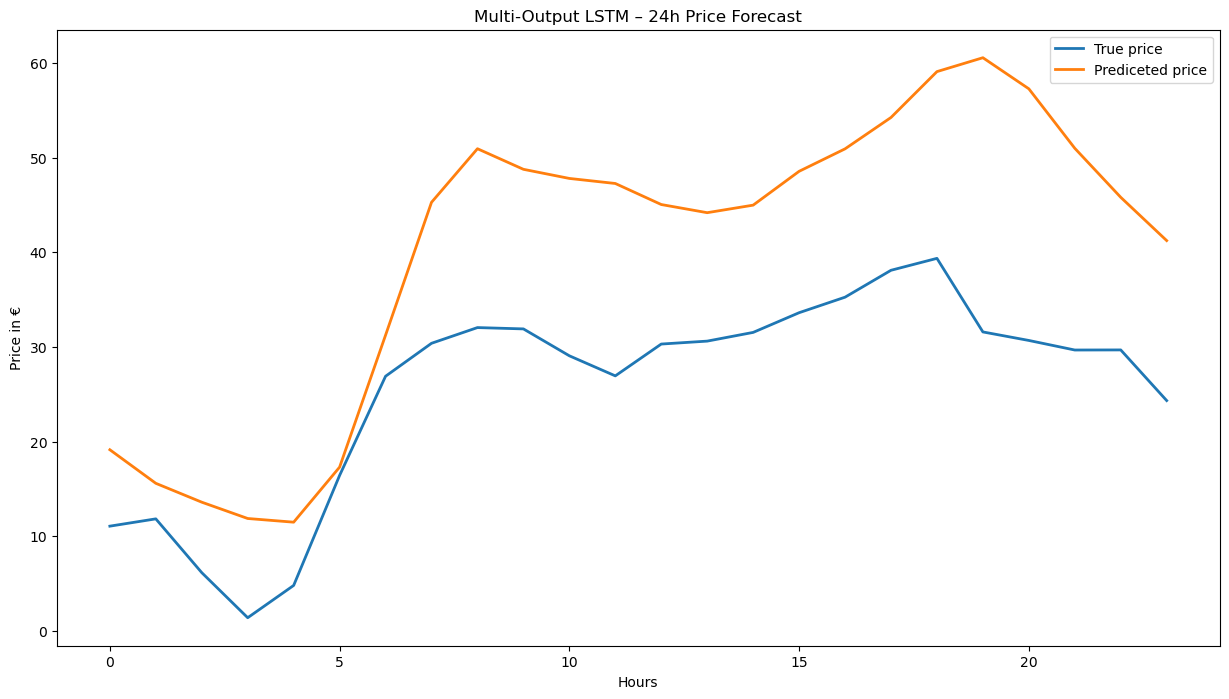

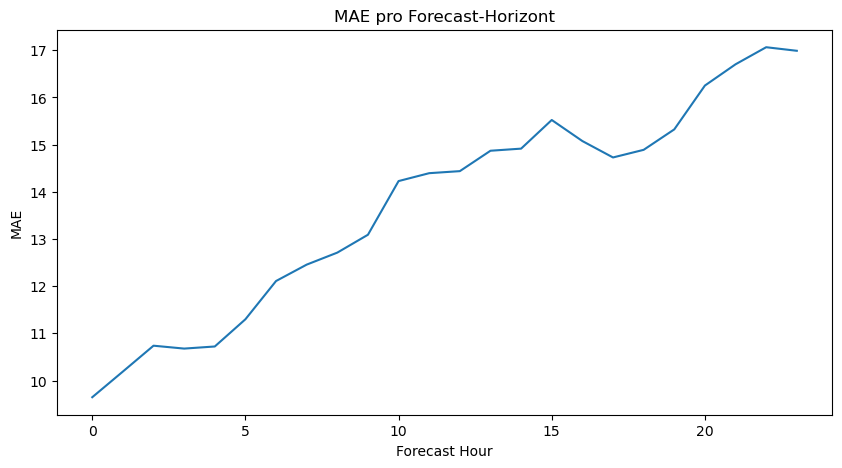

In [ ]:
from sklearn.preprocessing import StandardScaler
from keras.losses import Huber
from keras.metrics import MeanAbsoluteError, RootMeanSquaredError
from keras.callbacks import EarlyStopping

# Settings

SEQ = 24
HORIZON = 24


# Setup data

df = df_price_model.copy()
df = df.dropna().reset_index(drop=True)

features = [          
    'DE_load_forecast_entsoe_transparency',
    'wind_expected',
    'solar_expected',
    'DE_temperature',
    'Is_price_negative',
    'was_negative_1h_ago',
    'DE_radiation_direct_horizontal',
    'DE_radiation_diffuse_horizontal',
    'hour',
    'weekday',
    'month',
    'hour_sin',
    'hour_cos',
    'residual_load',
    'is_holiday',
    'is_winter',
    'is_summer',
    'price_lag_1h',
    'price_lag_2h',
    'price_lag_3h',
    'price_lag_12h',
    'price_lag_24h',
    'price_lag_48h',
    'price_lag_72h',
    'price_lag_168h',
    'price_lag_336h',
    'price_roll_mean_6h',
    'price_roll_mean_12h',
    'price_roll_mean_24h',
    'price_roll_std_6h',
    'price_roll_std_24h',
    'price_delta_1h',
    'load_lag_24h']

target = ['DE_LU_price_day_ahead']

# data scaling

scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_scaled = scaler_X.fit_transform(df[features])
y_scaled = scaler_y.fit_transform(df[target])

# Create Mulit-Ouput sequenz

def create_sequences_multi_output(X, y, seq_len, forecast_horizon):
    
    X_seq = []
    y_seq = []
    
    for i in range(len(X) - seq_len - forecast_horizon + 1):
        
        X_seq.append(
            X[i:i+seq_len]
        )
        
        y_seq.append(
            y[i+seq_len:i+seq_len+forecast_horizon].flatten()
        )
    
    return np.array(X_seq), np.array(y_seq)


X_seq, y_seq = create_sequences_multi_output(
    X_scaled,
    y_scaled,
    SEQ,
    HORIZON
)

print("X shape:", X_seq.shape)
print("y shape:", y_seq.shape)

# X: (samples, SEQ length, features)
# y: (samples, forecast horizon)


# Train/Test split

test_hours = 7*24 # one week

X_train = X_seq[:-test_hours] 
y_train = y_seq[:-test_hours] 

X_test= X_seq[-test_hours:]
y_test = y_seq[-test_hours:]

# Multi Output LSTM

""" model = Sequential()
model.add( LSTM( 64, input_shape=(SEQ_LEN, len(features)), return_sequences=False ) ) 
model.add(Dropout(0.2)) 
model.add(Dense(32, activation='relu'))
model.add(Dense(FORECAST_HORIZON)) # Mulit Output layer """


load_model = Sequential()

load_model.add(LSTM(128, return_sequences=True,
               input_shape=(SEQ_LEN, len(features))))

load_model.add(Dropout(0.2))

load_model.add(LSTM(64))

load_model.add(Dense(64, activation="relu"))

load_model.add(Dense(FORECAST_HORIZON))



load_model.compile(
    optimizer='adam',
    loss=Huber(delta=1.0),
    metrics=[
        MeanAbsoluteError(name="mae"),
        RootMeanSquaredError(name="rmse")
    ]
)

load_model.summary()



# Train Model

history = load_model.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=16,
    validation_split=0.1,
    verbose=2
)

# Forecast Mulit-Output

def forecast_multi_output(model, last_window, scaler_y):
    
    pred_scaled = model.predict(
        last_window[np.newaxis,:,:],
        verbose=0
    )[0]
    
    pred = scaler_y.inverse_transform(
        pred_scaled.reshape(-1,1)
    ).flatten()
    
    return pred


# Create predicted forecast

last_window = X_test[-1]

forecast_24h = forecast_multi_output(load_model, last_window, scaler_y)


# True outcome

y_true_24h = scaler_y.inverse_transform(
    y_test[-1].reshape(-1,1)
).flatten()


# Calculate MAE

mae = mean_absolute_error(
    y_true.flatten(),
    y_pred.flatten()
)

rmse = np.sqrt(mean_squared_error(
    y_true.flatten(),
    y_pred.flatten()
))

def smape(y_true, y_pred):
    return np.mean(
        2 * np.abs(y_pred - y_true) /
        (np.abs(y_true) + np.abs(y_pred) + 1e-8)
    ) * 100

smape_value = smape(
    y_true.flatten(),
    y_pred.flatten()
)

direction_acc = np.mean(
    np.sign(np.diff(y_true.flatten())) ==
    np.sign(np.diff(y_pred.flatten()))
)

print("Direction Accuracy:", direction_acc)

print("\nECHTE MODEL PERFORMANCE:")
print("MAE:", mae)
print("RMSE:", rmse)
print("sMAPE:", smape_value)
print("Direction Accuracy:", direction_acc)

#Plot one sample


plt.figure(figsize=(15,8))

plt.plot(y_true_24h, label='True price', linewidth=2)
plt.plot(forecast_24h, label= 'Prediceted price', linewidth=2)
plt.title('Multi-Output LSTM – 24h Price Forecast')
plt.xlabel('Hours')
plt.ylabel('Price in €')
plt.legend()
plt.plot()


# Evaluation 

# Predict for test set
y_pred_scaled = load_model.predict(X_test, verbose=0)

# Inverse Transform
y_pred = scaler_y.inverse_transform(
    y_pred_scaled.reshape(-1,1)
).reshape(y_pred_scaled.shape)

y_true = scaler_y.inverse_transform(
    y_test.reshape(-1,1)
).reshape(y_test.shape)

# Gesamt MAE
mae = mean_absolute_error(
    y_true.flatten(),
    y_pred.flatten()
)

# Gesamt MAPE
mape = np.mean(
    np.abs((y_true - y_pred) / y_true)
) * 100

print("\nECHTE MODEL PERFORMANCE:")
print("MAE:", mae)
print("MAPE:", mape, "%")

mae_per_hour = np.mean(np.abs(y_true - y_pred), axis=0)

plt.figure(figsize=(10,5))
plt.plot(mae_per_hour)
plt.title("MAE pro Forecast-Horizont")
plt.xlabel("Forecast Hour")
plt.ylabel("MAE")
plt.show()


## LSTM big modell fpr price forecast


X shape: (10405, 168, 33)
y shape: (10405, 2)


/Users/nikwe/opt/anaconda3/envs/ds_env/lib/python3.10/site-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_27"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_39 (LSTM)                  │ (None, 168, 64)        │        25,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_30 (Dropout)            │ (None, 168, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_40 (LSTM)                  │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_54 (Dense)                │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_55 (Dense)                │ (None, 2)              │            66 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 38,626 (150.88 KB)

 Trainable params: 38,626 (150.88 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
288/288 - 35s - 122ms/step - loss: 0.1110 - mae: 0.3313 - rmse: 0.5252 - val_loss: 0.0692 - val_mae: 0.2719 - val_rmse: 0.3812
Epoch 2/10
288/288 - 28s - 96ms/step - loss: 0.0456 - mae: 0.2095 - rmse: 0.3168 - val_loss: 0.0643 - val_mae: 0.2624 - val_rmse: 0.3651
Epoch 3/10
288/288 - 26s - 90ms/step - loss: 0.0383 - mae: 0.1925 - rmse: 0.2831 - val_loss: 0.0646 - val_mae: 0.2577 - val_rmse: 0.3716
Epoch 4/10
288/288 - 28s - 96ms/step - loss: 0.0361 - mae: 0.1856 - rmse: 0.2765 - val_loss: 0.0575 - val_mae: 0.2339 - val_rmse: 0.3525
Epoch 5/10
288/288 - 28s - 98ms/step - loss: 0.0324 - mae: 0.1760 - rmse: 0.2620 - val_loss: 0.0556 - val_mae: 0.2337 - val_rmse: 0.3436
Epoch 6/10
288/288 - 26s - 89ms/step - loss: 0.0303 - mae: 0.1703 - rmse: 0.2507 - val_loss: 0.0672 - val_mae: 0.2596 - val_rmse: 0.3825
Epoch 7/10
288/288 - 26s - 91ms/step - loss: 0.0279 - mae: 0.1637 - rmse: 0.2401 - val_loss: 0.0717 - val_mae: 0.2604 - val_rmse: 0.4017
Epoch 8/10
288/288 - 26s - 90ms/step - l

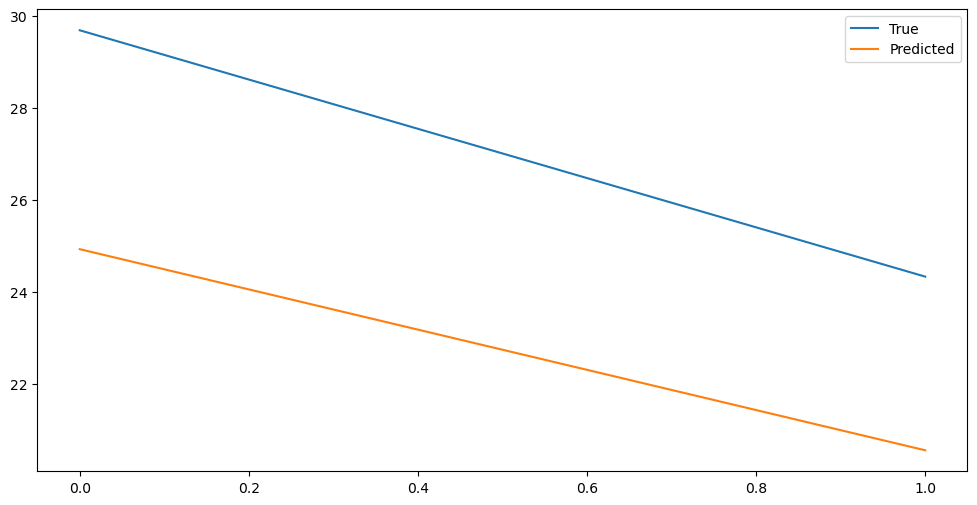

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from keras.losses import Huber
from keras.metrics import MeanAbsoluteError, RootMeanSquaredError
from keras.callbacks import EarlyStopping
from keras.models import Sequential
from keras.layers import LSTM, Dense, Dropout

# =========================
# SETTINGS (FIXED)
# =========================

SEQ = 168
HORIZON = 2

# =========================
# DATA PREP
# =========================

df = df_price_model.copy()
df = df.dropna().reset_index(drop=True)

target = ['DE_LU_price_day_ahead']

# =========================
# SCALING (CORRECT)
# =========================

scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_scaled = scaler_X.fit_transform(df[features])
y_scaled = scaler_y.fit_transform(df[target])

# =========================
# CREATE SEQUENCES
# =========================

def create_sequences_multi_output(X, y, seq_len, horizon):

    X_seq, y_seq = [], []

    for i in range(len(X) - seq_len - horizon + 1):

        X_seq.append(X[i:i+seq_len])

        y_seq.append(
            y[i+seq_len:i+seq_len+horizon].flatten()
        )

    return np.array(X_seq), np.array(y_seq)


X_seq, y_seq = create_sequences_multi_output(
    X_scaled,
    y_scaled,
    SEQ,
    HORIZON
)

print("X shape:", X_seq.shape)
print("y shape:", y_seq.shape)

# =========================
# TRAIN TEST SPLIT
# =========================

test_hours = 7 * 24

X_train = X_seq[:-test_hours]
y_train = y_seq[:-test_hours]

X_test = X_seq[-test_hours:]
y_test = y_seq[-test_hours:]

# =========================
# MODEL (IMPROVED)
# =========================

load_model = Sequential()

load_model.add(
    LSTM(64,
         return_sequences=True,
         input_shape=(SEQ, len(features)))
)

load_model.add(Dropout(0.2))

load_model.add(LSTM(32))



load_model.add(Dense(32, activation="relu"))

load_model.add(Dense(HORIZON))

load_model.compile(
    optimizer='adam',
    loss=Huber(delta=1.0),
    metrics=[
        MeanAbsoluteError(name="mae"),
        RootMeanSquaredError(name="rmse")
    ]
)

load_model.summary()

# =========================
# EARLY STOPPING (CRITICAL)
# =========================

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

# =========================
# TRAIN
# =========================

history = load_model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=2
)

# =========================
# FULL TEST PREDICTION
# =========================

y_pred_scaled = load_model.predict(X_test, verbose=0)

y_pred = scaler_y.inverse_transform(
    y_pred_scaled.reshape(-1,1)
).reshape(y_pred_scaled.shape)

y_true = scaler_y.inverse_transform(
    y_test.reshape(-1,1)
).reshape(y_test.shape)

# =========================
# METRICS
# =========================

mae = mean_absolute_error(
    y_true.flatten(),
    y_pred.flatten()
)

rmse = np.sqrt(
    mean_squared_error(
        y_true.flatten(),
        y_pred.flatten()
    )
)
r2 = r2_score(
    y_true.flatten(),
    y_pred.flatten()
)

def smape(y_true, y_pred):

    return np.mean(
        2 * np.abs(y_pred - y_true)
        /
        (np.abs(y_true) + np.abs(y_pred) + 1e-8)
    ) * 100


smape_value = smape(
    y_true.flatten(),
    y_pred.flatten()
)

direction_acc = np.mean(
    np.sign(np.diff(y_true.flatten()))
    ==
    np.sign(np.diff(y_pred.flatten()))
)

# =========================
# PRINT RESULTS
# =========================

print("\nMODEL PERFORMANCE")
print("MAE:", round(mae,2))
print("RMSE:", round(rmse,2))
print("R2:", round(r2,3))
print("sMAPE:", round(smape_value,2), "%")
print("Direction Accuracy:", round(direction_acc,3))

# =========================
# BASELINE COMPARISON
# =========================

lag_index = features.index("price_lag_24h")

baseline_scaled = X_test[:, -1, lag_index]

baseline = scaler_y.inverse_transform(
    baseline_scaled.reshape(-1,1)
).flatten()

baseline_true = y_true[:,0]

baseline_mae = mean_absolute_error(
    baseline_true,
    baseline
)

print("\nBASELINE MAE:", round(baseline_mae,2))

print(
    "Improvement:",
    round((baseline_mae-mae)/baseline_mae*100,2),
    "%"
)

# =========================
# PLOT
# =========================

plt.figure(figsize=(12,6))

plt.plot(y_true[-1], label="True")
plt.plot(y_pred[-1], label="Predicted")

plt.legend()

plt.show()

## XGBoost for price forecast

Original X shape: (10550, 24, 33)
Original y shape: (10550, 1)
Flattened X shape: (10550, 792)

Training XGBoost...

MODEL PERFORMANCE (XGBOOST)
MAE: 2.11
RMSE: 3.15
R2: 0.912
sMAPE: 14.85 %
Direction Accuracy: 0.695

BASELINE MAE: 5.78
Improvement: 63.45 %


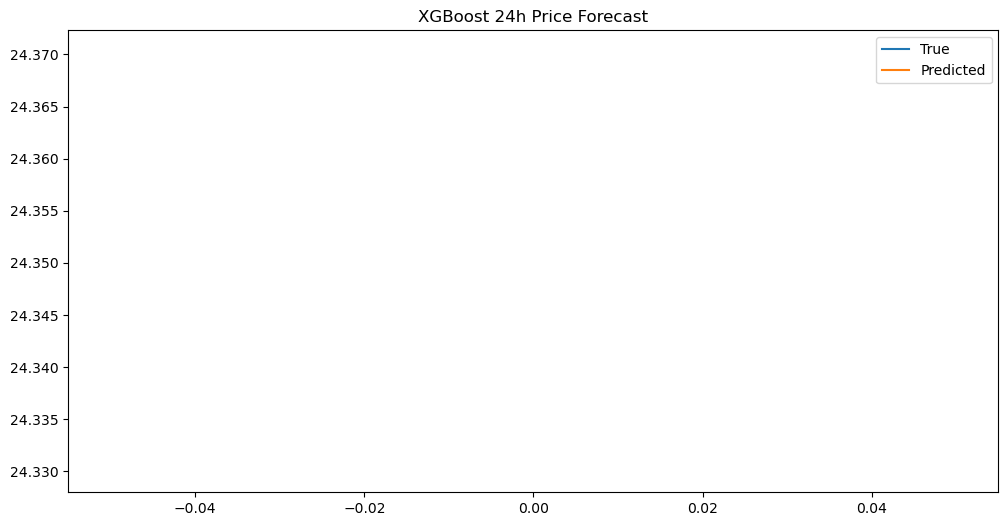

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.multioutput import MultiOutputRegressor

from xgboost import XGBRegressor

# =========================
# SETTINGS
# =========================

SEQ = 24
HORIZON = 1

# =========================
# DATA PREP
# =========================

df = df_price_model.copy()
df = df.dropna().reset_index(drop=True)

target = ['DE_LU_price_day_ahead']

# =========================
# SCALING
# =========================

scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_scaled = scaler_X.fit_transform(df[features])
y_scaled = scaler_y.fit_transform(df[target])

# =========================
# CREATE SEQUENCES
# =========================

def create_sequences_multi_output(X, y, seq_len, horizon):

    X_seq, y_seq = [], []

    for i in range(len(X) - seq_len - horizon + 1):

        X_seq.append(X[i:i+seq_len])
        y_seq.append(y[i+seq_len:i+seq_len+horizon].flatten())

    return np.array(X_seq), np.array(y_seq)


X_seq, y_seq = create_sequences_multi_output(
    X_scaled,
    y_scaled,
    SEQ,
    HORIZON
)

print("Original X shape:", X_seq.shape)
print("Original y shape:", y_seq.shape)

# =========================
# FLATTEN FOR XGBOOST
# =========================

n_samples = X_seq.shape[0]
n_features_total = X_seq.shape[1] * X_seq.shape[2]

X_seq_flat = X_seq.reshape(n_samples, n_features_total)

print("Flattened X shape:", X_seq_flat.shape)

# =========================
# TRAIN TEST SPLIT
# =========================

test_hours =  7 * 24

X_train = X_seq_flat[:-test_hours]
y_train = y_seq[:-test_hours]

X_test = X_seq_flat[-test_hours:]
y_test = y_seq[-test_hours:]

# =========================
# XGBOOST MODEL
# =========================

load_model = XGBRegressor(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    tree_method="hist",
    random_state=42
)


print("\nTraining XGBoost...")

load_model.fit(X_train, y_train)

# =========================
# FULL TEST PREDICTION
# =========================

y_pred_scaled = load_model.predict(X_test)

# inverse transform
y_pred = scaler_y.inverse_transform(
    y_pred_scaled.reshape(-1,1)
).reshape(y_pred_scaled.shape)

y_true = scaler_y.inverse_transform(
    y_test.reshape(-1,1)
).reshape(y_test.shape)

# =========================
# METRICS
# =========================

mae = mean_absolute_error(
    y_true.flatten(),
    y_pred.flatten()
)

rmse = np.sqrt(
    mean_squared_error(
        y_true.flatten(),
        y_pred.flatten()
    )
)

r2 = r2_score(
    y_true.flatten(),
    y_pred.flatten()
)

def smape(y_true, y_pred):

    return np.mean(
        2*np.abs(y_pred - y_true) /
        (np.abs(y_true) + np.abs(y_pred) + 1e-8)
    ) * 100


smape_value = smape(
    y_true.flatten(),
    y_pred.flatten()
)

direction_acc = np.mean(
    np.sign(np.diff(y_true.flatten()))
    ==
    np.sign(np.diff(y_pred.flatten()))
)

# =========================
# PRINT RESULTS
# =========================

print("\nMODEL PERFORMANCE (XGBOOST)")

print("MAE:", round(mae,2))
print("RMSE:", round(rmse,2))
print("R2:", round(r2,3))
print("sMAPE:", round(smape_value,2), "%")
print("Direction Accuracy:", round(direction_acc,3))

# =========================
# BASELINE COMPARISON
# =========================

lag_index = features.index("price_lag_24h")

baseline_scaled = X_seq[-test_hours:, -1, lag_index]

baseline = scaler_y.inverse_transform(
    baseline_scaled.reshape(-1,1)
).flatten()

baseline_true = y_true[:,0]

baseline_mae = mean_absolute_error(
    baseline_true,
    baseline
)

print("\nBASELINE MAE:", round(baseline_mae,2))

print(
    "Improvement:",
    round((baseline_mae-mae)/baseline_mae*100,2),
    "%"
)

# =========================
# PLOT
# =========================

plt.figure(figsize=(12,6))

plt.plot(y_true[-1], label="True")
plt.plot(y_pred[-1], label="Predicted")

plt.title("XGBoost 24h Price Forecast")

plt.legend()

plt.show()